Business Problem

A telecom company wants to understand why customers leave (churn) and identify the factors that influence customer retention. The goal is to provide recommendations that reduce customer churn and improve customer loyalty.

We just imported the python libraries which is pandas and numpy. To read the file and the df.head() helps us to return the top 5 rows fromn the data set.

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


These two commands helps us to understand the structure of the data set. In this We have 7043 rows and then 21 columns.

In [4]:
df.shape
df.columns
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


We just used the command df.info() to get the number of row and columns , Data types and missing values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We are just understanding the dataset with the following commands with the output.

In [7]:
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.nunique()
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

we jsut used the command shape[0] to get the total number of customers then shape[1] helps us to determine the total number of the columns.

In [8]:
print(df.shape[0])
print(df.shape[1])
df["Churn"].value_counts()
df["InternetService"].value_counts()
df["Contract"].value_counts()
df["PaymentMethod"].value_counts()



7043
21


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

We created a copy of our data. Because it helps us to save our original data as it is.
Then we just found the datatype of our totalcharges.

In [9]:
df = df.copy()
df["TotalCharges"].dtype

dtype('O')

We just converted the datatype of totalcharges from Object(text) to numerical.

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

We just checking for null values from our data.

In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Here we used command dropna which  helps us to remove the missing value rows.
And after that we just checked for null values now every column has 0 null values.

In [12]:
df = df.dropna()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Here , now we have a float for the total charges column instead of object.

In [13]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Now we have creating a chart for the gender of customers as per their count with the python library which is matplot lib.

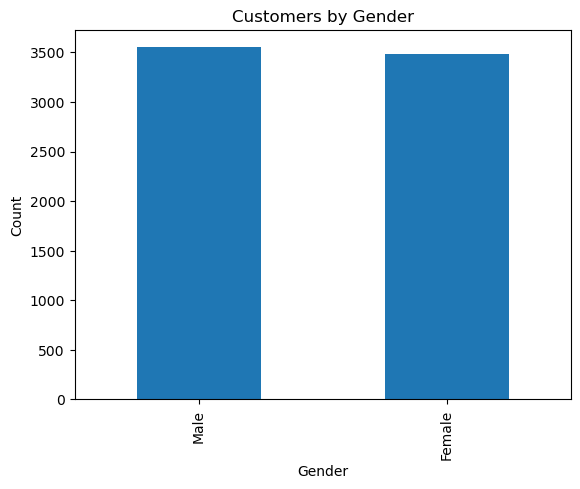

In [14]:
import matplotlib.pyplot as plt
gender = df["gender"].value_counts()

gender.plot(kind="bar")

plt.title("Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Here we generated an another plot with the data of churn of customers.

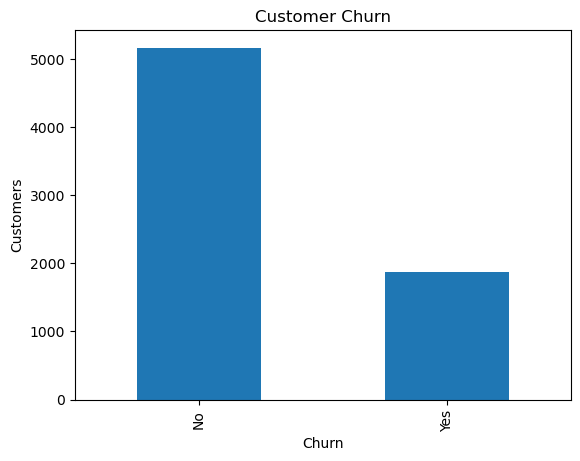

In [15]:
import matplotlib.pyplot as plt
churn = df["Churn"].value_counts()

churn.plot(kind="bar")

plt.title("Customer Churn")

plt.xlabel("Churn")

plt.ylabel("Customers")

plt.show()

Here we have generated an another plot which shows the data of payment methods of the customers.

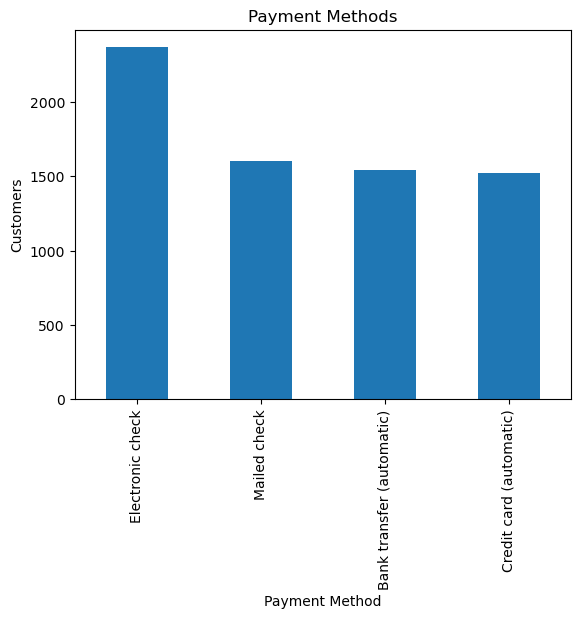

In [16]:
import matplotlib.pyplot as plt
payment_method = df["PaymentMethod"].value_counts()

payment_method.plot(kind="bar")

plt.title("Payment Methods")

plt.xlabel("Payment Method")

plt.ylabel("Customers")

plt.show()

Here we have generated an another plot which explains about the internet service used by the customers.

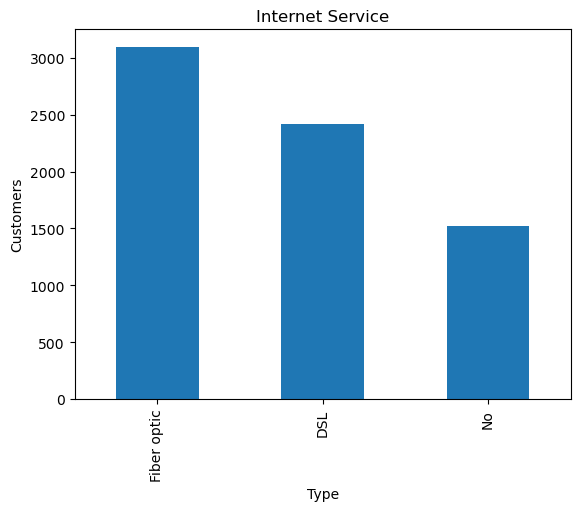

In [17]:
import matplotlib.pyplot as plt
internet = df["InternetService"].value_counts()

internet.plot(kind="bar")

plt.title("Internet Service")

plt.xlabel("Type")

plt.ylabel("Customers")

plt.show()

Here we have generated a plot which shows the payment methods which is used by the customers.

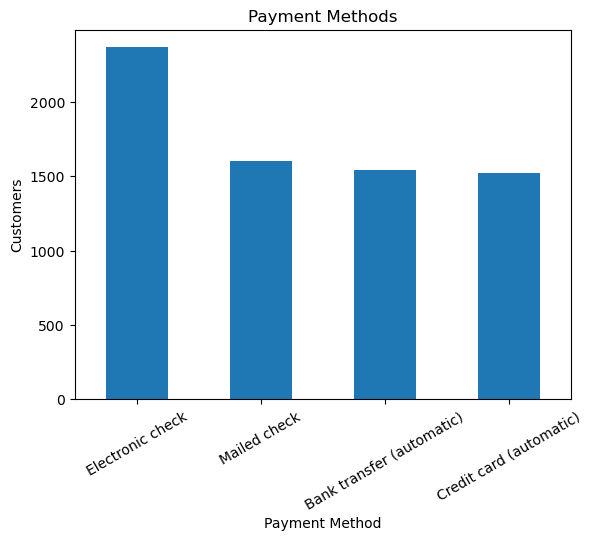

In [18]:
import matplotlib.pyplot as plt
payment = df["PaymentMethod"].value_counts()

payment.plot(kind="bar")

plt.title("Payment Methods")

plt.xlabel("Payment Method")

plt.ylabel("Customers")

plt.xticks(rotation=30)

plt.show()

Here we have generated a plot which explains about the seniour citizens distribution in the customers counts of the data.

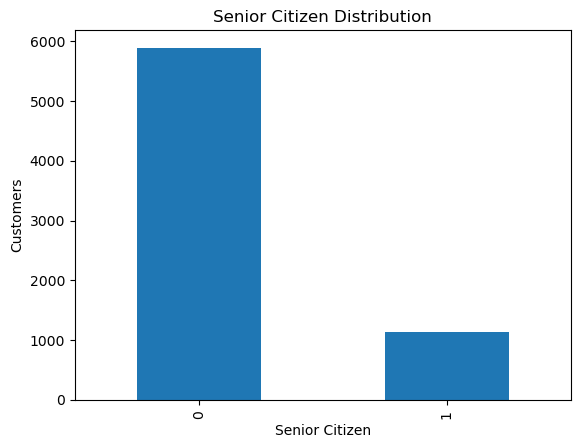

In [19]:
import matplotlib.pyplot as plt
senior = df["SeniorCitizen"].value_counts()

senior.plot(kind="bar")

plt.title("Senior Citizen Distribution")

plt.xlabel("Senior Citizen")

plt.ylabel("Customers")

plt.show()

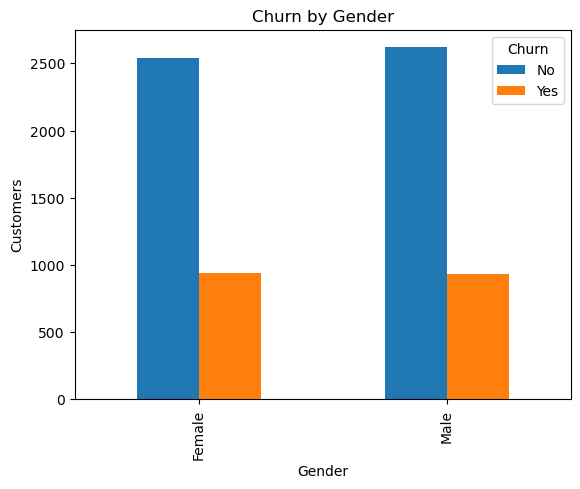

In [20]:
import matplotlib.pyplot as plt
gender_churn = pd.crosstab(df["gender"], df["Churn"])

gender_churn.plot(kind="bar")

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Customers")

plt.show()

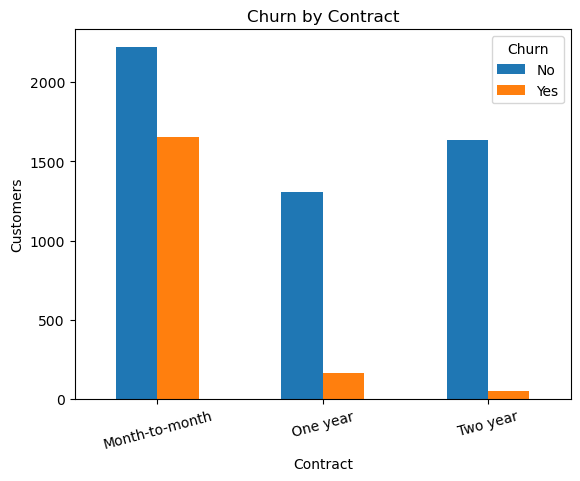

In [21]:
import matplotlib.pyplot as plt
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar")

plt.title("Churn by Contract")
plt.xlabel("Contract")
plt.ylabel("Customers")

plt.xticks(rotation=15)

plt.show()

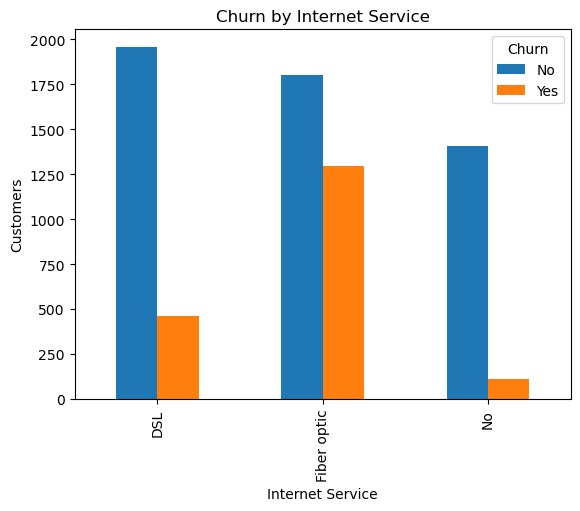

In [22]:
import matplotlib.pyplot as plt
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

internet_churn.plot(kind="bar")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

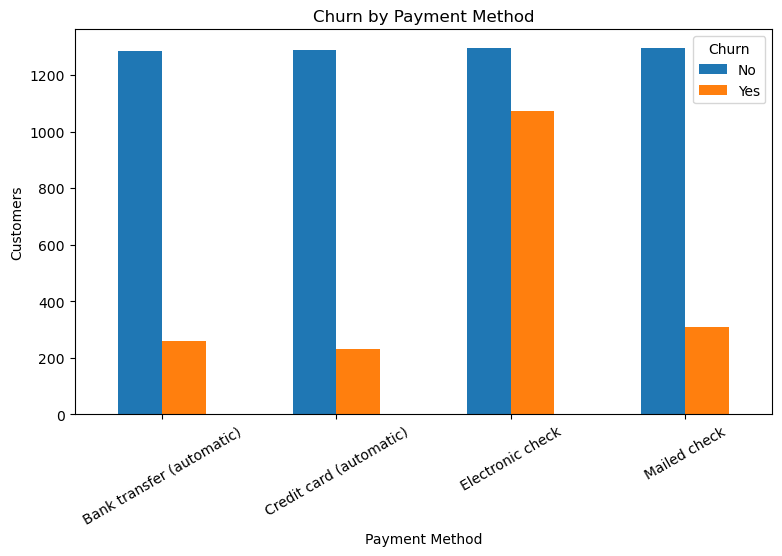

In [23]:
import matplotlib.pyplot as plt
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"])

payment_churn.plot(kind="bar", figsize=(9,5))

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customers")

plt.xticks(rotation=30)

plt.show()

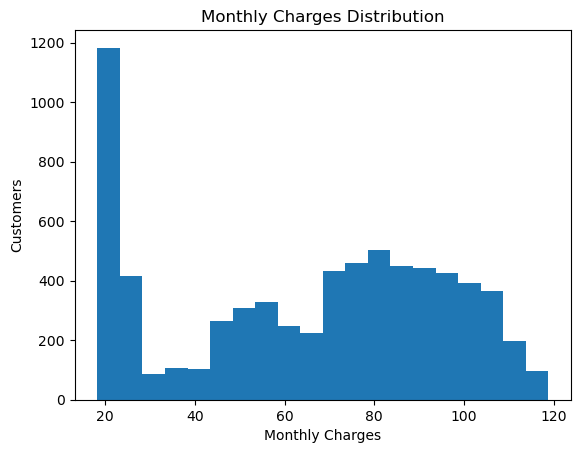

In [24]:
import matplotlib.pyplot as plt
df["MonthlyCharges"].plot(kind="hist", bins=20)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")

plt.show()

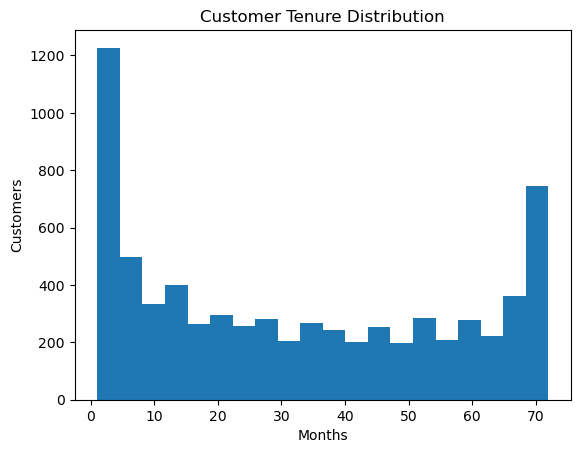

In [25]:
import matplotlib.pyplot as plt
df["tenure"].plot(kind="hist", bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Months")
plt.ylabel("Customers")

plt.show()

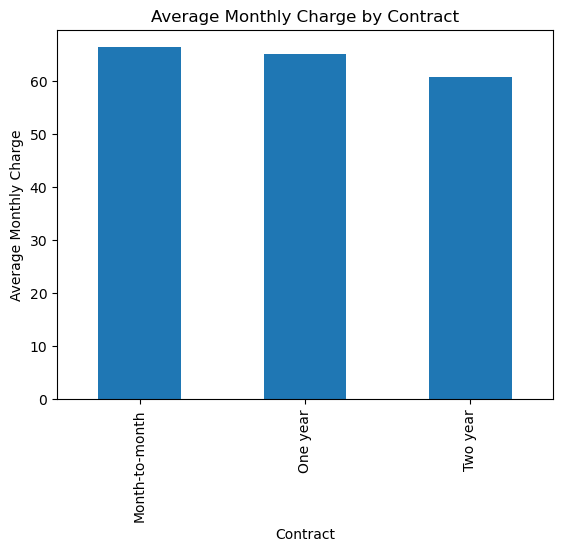

In [26]:
import matplotlib.pyplot as plt
avg_charge = df.groupby("Contract")["MonthlyCharges"].mean()

avg_charge.plot(kind="bar")

plt.title("Average Monthly Charge by Contract")
plt.xlabel("Contract")
plt.ylabel("Average Monthly Charge")

plt.show()

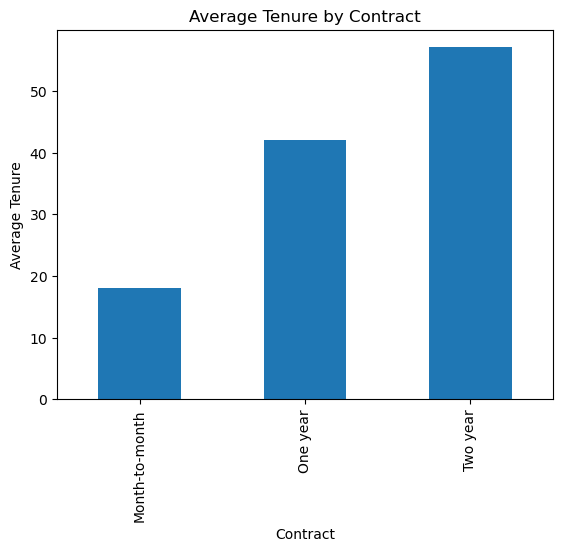

In [27]:
import matplotlib.pyplot as plt
avg_tenure = df.groupby("Contract")["tenure"].mean()

avg_tenure.plot(kind="bar")

plt.title("Average Tenure by Contract")
plt.xlabel("Contract")
plt.ylabel("Average Tenure")

plt.show()

It shows the number of customers who left and stayed.

In [28]:
import matplotlib.pyplot as plt
churn_percent = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percent)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


Final_Insights from the analysis: 

Insight 1

Customers on Month-to-Month contracts have the highest churn rate.

Insight 2

Electronic Check customers churn more than customers using automatic payment methods.

Insight 3

Customers with Fiber Optic Internet churn more.

Insight 4

Senior citizens have slightly higher churn.

Insight 5

Customers staying for longer periods usually churn less.